In [3]:
!pip install -q langchain-mistralai langgraph pydantic python-dotenv

In [13]:
from google.colab import userdata
import os
os.environ["MISTRAL_API_KEY"] = userdata.get('MISTRAL_API_KEY')

In [14]:
from dotenv import load_dotenv
load_dotenv()

from langchain_mistralai import ChatMistralAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [15]:
# ----------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------
store = InMemoryStore()

user_id = "u1"

user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Hamza"})
store.put(user_details, "profile_2", {"data": "Final-year Software Engineering student at NUST"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building a LangChain/LangGraph chatbot project (labgGraph)"})

In [16]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Hamza...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your labgGraph LangGraph chatbot project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..."
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user's memory (which may be empty) is provided as: {user_details_content}
"""

In [17]:
# DELIBERATELY hardcoded -- see MISTRAL_MODEL_LIMITS.md: mistral-small-latest
# has zero request allowance on many accounts (hard 429).
llm = ChatMistralAI(model="ministral-8b-latest")

In [18]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

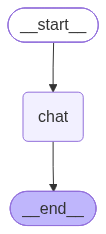

In [19]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [20]:
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)

Hey Hamza!

**Gen AI (Generative AI)** is like a super-smart **creative assistant** that can generate new content—text, images, code, or even music—based on prompts or patterns it’s learned from.

### **Simple Breakdown:**
1. **Trained on Data** – It learns from huge datasets (e.g., books, code, images).
2. **Predicts Patterns** – Instead of just answering questions, it *creates* new things (like writing code, drafting emails, or designing art).
3. **Flexible & Adaptable** – You can ask it to write Python scripts, summarize research papers, or even debug your `labgGraph` project.

### **Examples in Python (since you prefer that!):**
- **Code Generation**: *"Write a Flask API endpoint for user auth."*
- **Text Generation**: *"Summarize this paper in 3 bullet points."*
- **Debugging**: *"Fix this LangChain error for me."*

### **Why It’s Useful for Your Project (labgGraph):**
- Auto-generate prompts for your chatbot.
- Quickly prototype responses.
- Even assist in debugging (though alway

##Part 2 — Chatbot Creating New Memories

In [21]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_mistralai import ChatMistralAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [22]:
store = InMemoryStore()

In [23]:
extractor_llm = ChatMistralAI(model="ministral-8b-latest", temperature=0)

In [24]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store")

In [25]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [26]:
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")

    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

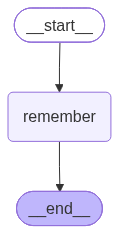

In [27]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [28]:
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Hamza"}]}, config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [29]:
res = graph.invoke({"messages": [{"role": "user", "content": "I'm a final-year Software Engineering student at NUST"}]}, config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [30]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]}, config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [31]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

User identifies themselves as Hamza.
User is a final-year Software Engineering student at NUST.
User prefers Python as their favorite programming language.


###Part 3 — Chatbot Creating New Memories (Without Duplication)

In [32]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_mistralai import ChatMistralAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [33]:
store = InMemoryStore()

In [34]:
memory_llm = ChatMistralAI(model="ministral-8b-latest", temperature=0)

In [35]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [36]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [37]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [38]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [39]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

In [40]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

In [41]:
config = {"configurable": {"user_id": "u1"}}

In [42]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Hamza"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [43]:
# Likely duplicate of the first memory -> is_new should be false -> saved=0
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)


Assistant: Noted.


In [44]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

User's name is Hamza.


#Part 4 — Merged Workflow (Remember + Chat)

In [45]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_mistralai import ChatMistralAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [46]:
store = InMemoryStore()

In [47]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Hamza...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your labgGraph LangGraph chatbot project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user's memory (which may be empty) is provided as: {user_details_content}
"""

In [48]:
memory_llm = ChatMistralAI(model="ministral-8b-latest", temperature=0)

In [49]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory")
    is_new: bool = Field(description="True if new, false if duplicate")

In [50]:
class MemoryDecision(BaseModel):
    should_write: bool
    memories: List[MemoryItem] = Field(default_factory=list)

In [51]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [52]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list.
"""

Node 1: remember (write-only, returns nothing to messages)

In [53]:
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})

    return {}  # no message change

In [54]:
chat_llm = ChatMistralAI(model="ministral-8b-latest")

Node 2: chat (read-only, produces the actual reply)

In [55]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

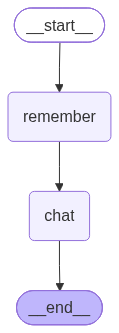

In [56]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [57]:
config = {"configurable": {"user_id": "u1"}}

In [58]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Hamza"}]}, config)
result['messages'][-1].content

'Hello Hamza! Nice to meet you—finally putting a name to the face (or the chatbot interactions 😄). How’s it going? How can I assist you today—whether it’s diving deeper into your **LangGraph** project, troubleshooting something, or just brainstorming ideas?\n\n*(Just to recap: You’re the Hamza behind the LangGraph chatbot work, right? Let me know if I’ve got that right—or if there’s anything else I should know to make this chat extra helpful!)*\n\n---\n**Quick follow-ups to kick things off (pick what resonates!):**\n1. **LangGraph update:** How’s the chatbot project progressing? Any new features or roadblocks lately?\n2. **Tech stack:** Are you still leaning into tools like GraphQL, LangChain, or something else for this?\n3. **Quick win:** Need help debugging a specific part (e.g., node logic, integration, or UI)?'

In [59]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User identifies themselves as Hamza.


In [60]:
result = graph.invoke({"messages": [{"role": "user", "content": "I'm a final-year Software Engineering student at NUST"}]}, config)
print(result['messages'][-1].content)

Hey Hamza! It’s great to hear from you—NUST is an amazing place for Software Engineering, and you’re clearly making the most of it as a final-year student. How’s your project work going? Are you diving into anything exciting like AI, web development, or maybe even your thesis?

Since you’re in your final year, I’m guessing you’re juggling a lot—coursework, projects, and maybe even internship applications. What’s been the most challenging (or rewarding) part so far?

---
**3 follow-up questions tailored to you:**
1. Are you working on anything specific right now—like a capstone project, research, or a side passion project (e.g., a startup idea, open-source contributions, or a personal tool)?
2. Do you have a preferred tech stack or framework (e.g., Python/Django, React, LangGraph, or something else) that you’d like to explore further?
3. Since you’re near graduation, are you thinking about career paths, freelancing, or further studies? I’d love to help brainstorm options based on your i

In [61]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User identifies themselves as Hamza.
User Hamza is a final-year student in Software Engineering.


##third turn: a question unrelated to memory, but should still be personalized

In [62]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Hey Hamza! Great question—let me break down **Generative AI (GenAI)** in a way that connects to what you're likely working on in your **Software Engineering** studies.

### **GenAI in Simple Terms**
Imagine you’re writing a **chatbot** (like your *LangGraph* project) or building a **code assistant**—GenAI is the tech that lets it:
1. **Generate new content** (text, images, code, etc.) *on its own*—not just repeat what it’s trained on.
2. **Understand and mimic patterns** from data (like how you’d train a model on your lab’s datasets).
3. **Adapt to tasks** you define (e.g., auto-completing code snippets, drafting emails, or even designing UI mockups).

---
### **How It Works (For a Software Engineer)**
- **Input**: A prompt (e.g., *"Write a Python function to sort a list"*).
- **Model**: A neural network (like LLMs—Large Language Models) predicts the most likely next words/tokens based on *statistical patterns* in its training data.
- **Output**: A generated response (e.g., your functi

In [63]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User identifies themselves as Hamza.
User Hamza is a final-year student in Software Engineering.
